# Pneumonia Detection from Chest X-Rays

Pneumonia is a lung infection that inflames the air sacs (alveoli), potentially filling them with fluid. It remains one of the leading causes of hospitalization and mortality, particularly among children under 5. Diagnosis typically relies on chest X-ray interpretation by trained radiologists — a process that can be time-consuming and subject to human error.

This project builds a **Convolutional Neural Network (CNN)** to automatically classify chest X-ray images as either **Normal** or **Pneumonia**, aiming to assist in faster and more consistent screening.

In [ ]:
import numpy as np
import pandas as pd
import os

# Download the chest X-ray dataset
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Dataset downloaded to:", path)

# Locate the chest_xray root directory
for root, dirs, files in os.walk(path):
    if 'chest_xray' in dirs:
        DATA_DIR = os.path.join(root, 'chest_xray')
        break

print("Data directory:", DATA_DIR)

c:\Users\RRIBEI44\Documents\personal_project\modelagem_comp_2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded to: C:\Users\RRIBEI44\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2
Data directory: C:\Users\RRIBEI44\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray


# Import Libraries

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import ReduceLROnPlateau
import cv2
import os

# About the Dataset

The dataset contains **5,863 chest X-ray images** (JPEG) organized into 3 splits — `train`, `test`, and `val` — each with two subfolders: `PNEUMONIA` and `NORMAL`.

The images are anterior-posterior chest radiographs from pediatric patients (ages 1–5) at Guangzhou Women and Children's Medical Center. Each image underwent quality screening, and final diagnoses were confirmed by two expert physicians with a third reviewer for the evaluation set.

In [ ]:
labels = ['PNEUMONIA', 'NORMAL']
img_size = 150

def get_training_data(data_dir):
    """Load images from directory, resize to img_size, and pair with class labels."""
    data = [] 
    for label in labels: 
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)
        for img in os.listdir(path):
            try:
                img_arr = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                resized_arr = cv2.resize(img_arr, (img_size, img_size))
                data.append([resized_arr, class_num])
            except Exception as e:
                print(e)
    return np.array(data, dtype=object)

# Load and Prepare the Data

In [8]:
train = get_training_data(os.path.join(DATA_DIR, 'train'))
test = get_training_data(os.path.join(DATA_DIR, 'test'))
val = get_training_data(os.path.join(DATA_DIR, 'val'))

# Exploratory Data Analysis

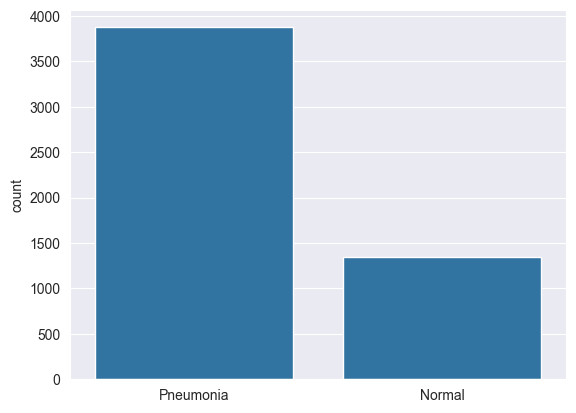

In [9]:
l = []
for i in train:
    if(i[1] == 0):
        l.append("Pneumonia")
    else:
        l.append("Normal")
sns.set_style('darkgrid')
sns.countplot(x=l)
plt.show()

The class distribution is clearly imbalanced — there are significantly more pneumonia samples than normal ones. We'll address this later with data augmentation.

### Sample Images from Each Class

Text(0.5, 1.0, 'NORMAL')

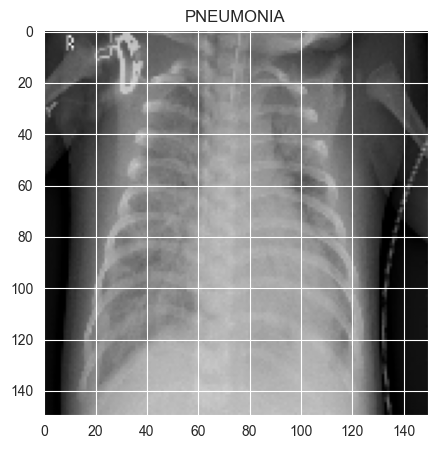

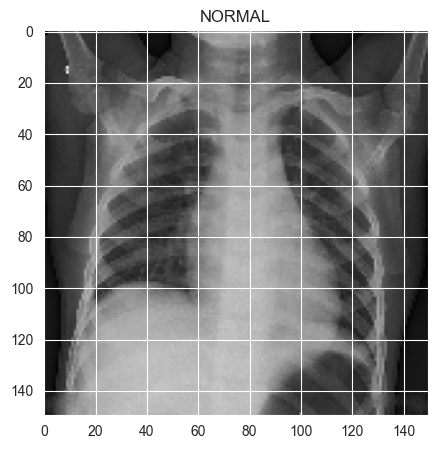

In [10]:
plt.figure(figsize = (5,5))
plt.imshow(train[0][0], cmap='gray')
plt.title(labels[train[0][1]])

plt.figure(figsize = (5,5))
plt.imshow(train[-1][0], cmap='gray')
plt.title(labels[train[-1][1]])

In [11]:
x_train = []
y_train = []

x_val = []
y_val = []

x_test = []
y_test = []

for feature, label in train:
    x_train.append(feature)
    y_train.append(label)

for feature, label in test:
    x_test.append(feature)
    y_test.append(label)
    
for feature, label in val:
    x_val.append(feature)
    y_val.append(label)

### Pixel Normalization

Scaling pixel values from [0, 255] to [0, 1] helps the network converge faster during training and reduces sensitivity to lighting variations across images.

In [ ]:
# Scale pixel values to [0, 1]
x_train = np.array(x_train) / 255
x_val = np.array(x_val) / 255
x_test = np.array(x_test) / 255

In [ ]:
# Reshape to (samples, height, width, channels) for CNN input
x_train = x_train.reshape(-1, img_size, img_size, 1)
y_train = np.array(y_train)

x_val = x_val.reshape(-1, img_size, img_size, 1)
y_val = np.array(y_val)

x_test = x_test.reshape(-1, img_size, img_size, 1)
y_test = np.array(y_test)

# Data Augmentation

To combat overfitting and the class imbalance observed earlier, we apply real-time data augmentation during training. This artificially expands the effective dataset size by applying random geometric transformations (rotations, shifts, flips, zooms) to each batch — producing varied versions of the same images while preserving their labels.

In [ ]:
# Configure the image data generator with augmentation parameters
datagen = ImageDataGenerator(
    featurewise_center=False,
    samplewise_center=False,
    featurewise_std_normalization=False,
    samplewise_std_normalization=False,
    zca_whitening=False,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=False,
)

datagen.fit(x_train)

**Augmentation configuration:**
- Random rotation up to ±30°
- Random zoom up to 20%
- Horizontal shift up to 10% of width
- Vertical shift up to 10% of height
- Random horizontal flips

These transformations simulate natural variations in how X-rays are captured (patient positioning, distance from camera, etc.).

# Model Definition and Training

We build a sequential CNN with progressively deeper convolutional blocks (32 → 64 → 64 → 128 → 256 filters), each followed by Batch Normalization and MaxPooling. Dropout is applied at increasing rates to regularize the network.

In [15]:
model = Sequential()
model.add(Conv2D(32 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu' , input_shape = (150,150,1)))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(64 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(Dropout(0.1))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(64 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(128 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(256 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Flatten())
model.add(Dense(units = 128 , activation = 'relu'))
model.add(Dropout(0.2))
model.add(Dense(units = 1 , activation = 'sigmoid'))
model.compile(optimizer = "rmsprop" , loss = 'binary_crossentropy' , metrics = ['accuracy'])
model.summary()

c:\Users\RRIBEI44\Documents\personal_project\modelagem_comp_2\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 38, 38, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 38, 38, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 19, 19, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 19, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 1,246,401 (4.75 MB)

 Trainable params: 1,245,313 (4.75 MB)

 Non-trainable params: 1,088 (4.25 KB)

In [16]:
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience = 2, verbose=1,factor=0.3, min_lr=0.000001)

In [17]:
history = model.fit(datagen.flow(x_train,y_train, batch_size = 32) ,epochs = 12 , validation_data = datagen.flow(x_val, y_val) ,callbacks = [learning_rate_reduction])

Epoch 1/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 152s 915ms/step - accuracy: 0.8321 - loss: 0.5615 - val_accuracy: 0.5000 - val_loss: 33.5810 - learning_rate: 0.0010
Epoch 2/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 154s 943ms/step - accuracy: 0.8984 - loss: 0.2689 - val_accuracy: 0.5000 - val_loss: 74.8321 - learning_rate: 0.0010
Epoch 3/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 886ms/step - accuracy: 0.9192 - loss: 0.2293
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
163/163 ━━━━━━━━━━━━━━━━━━━━ 145s 887ms/step - accuracy: 0.9145 - loss: 0.2195 - val_accuracy: 0.5000 - val_loss: 46.0278 - learning_rate: 0.0010
Epoch 4/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 145s 888ms/step - accuracy: 0.9465 - loss: 0.1532 - val_accuracy: 0.5000 - val_loss: 43.8858 - learning_rate: 3.0000e-04
Epoch 5/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 886ms/step - accuracy: 0.9525 - loss: 0.1333
Epoch 5: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
163/163 ━━━━━━━━━━━━━━━━━━━━ 145s 887ms/step - accu

In [18]:
print("Loss of the model is - " , model.evaluate(x_test,y_test)[0])
print("Accuracy of the model is - " , model.evaluate(x_test,y_test)[1]*100 , "%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.9135 - loss: 0.2524
Loss of the model is -  0.2524360716342926
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - accuracy: 0.9135 - loss: 0.2524
Accuracy of the model is -  91.34615659713745 %


# Model Evaluation and Analysis

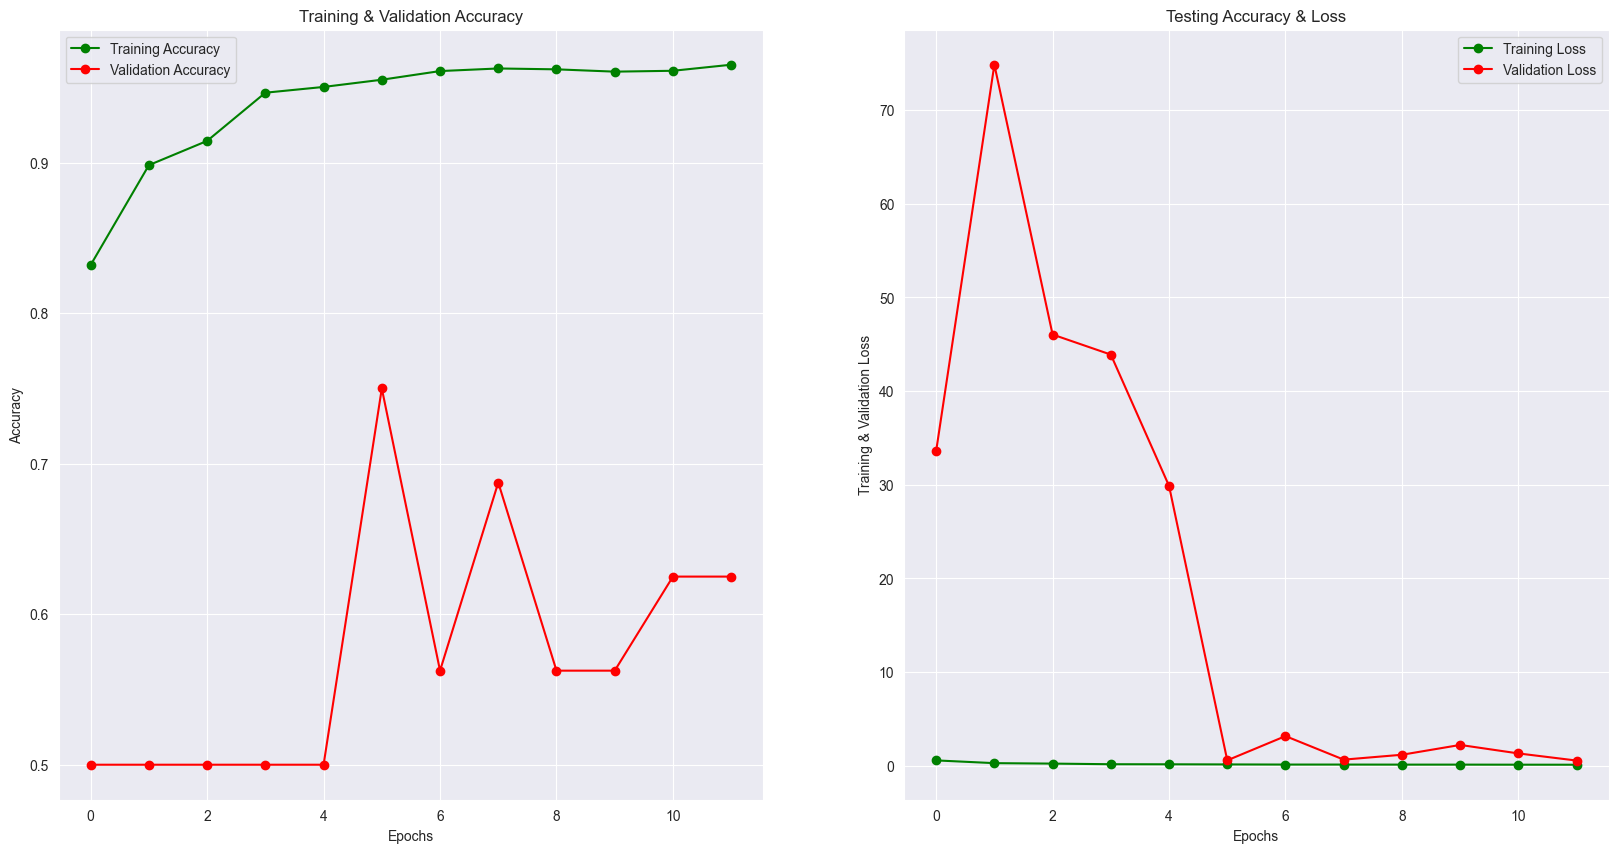

In [19]:
epochs = [i for i in range(12)]
fig , ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
fig.set_size_inches(20,10)

ax[0].plot(epochs , train_acc , 'go-' , label = 'Training Accuracy')
ax[0].plot(epochs , val_acc , 'ro-' , label = 'Validation Accuracy')
ax[0].set_title('Training & Validation Accuracy')
ax[0].legend()
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Accuracy")

ax[1].plot(epochs , train_loss , 'g-o' , label = 'Training Loss')
ax[1].plot(epochs , val_loss , 'r-o' , label = 'Validation Loss')
ax[1].set_title('Testing Accuracy & Loss')
ax[1].legend()
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Training & Validation Loss")
plt.show()

In [20]:
predictions = (model.predict(x_test) > 0.5).astype("int32")
predictions = predictions.reshape(1,-1)[0]
predictions[:15]

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0], dtype=int32)

In [21]:
print(classification_report(y_test, predictions, target_names = ['Pneumonia (Class 0)','Normal (Class 1)']))

                     precision    recall  f1-score   support

Pneumonia (Class 0)       0.93      0.93      0.93       390
   Normal (Class 1)       0.88      0.88      0.88       234

           accuracy                           0.91       624
          macro avg       0.91      0.91      0.91       624
       weighted avg       0.91      0.91      0.91       624



In [22]:
cm = confusion_matrix(y_test,predictions)
cm

array([[363,  27],
       [ 27, 207]])

In [23]:
cm = pd.DataFrame(cm , index = ['0','1'] , columns = ['0','1'])

<Axes: >

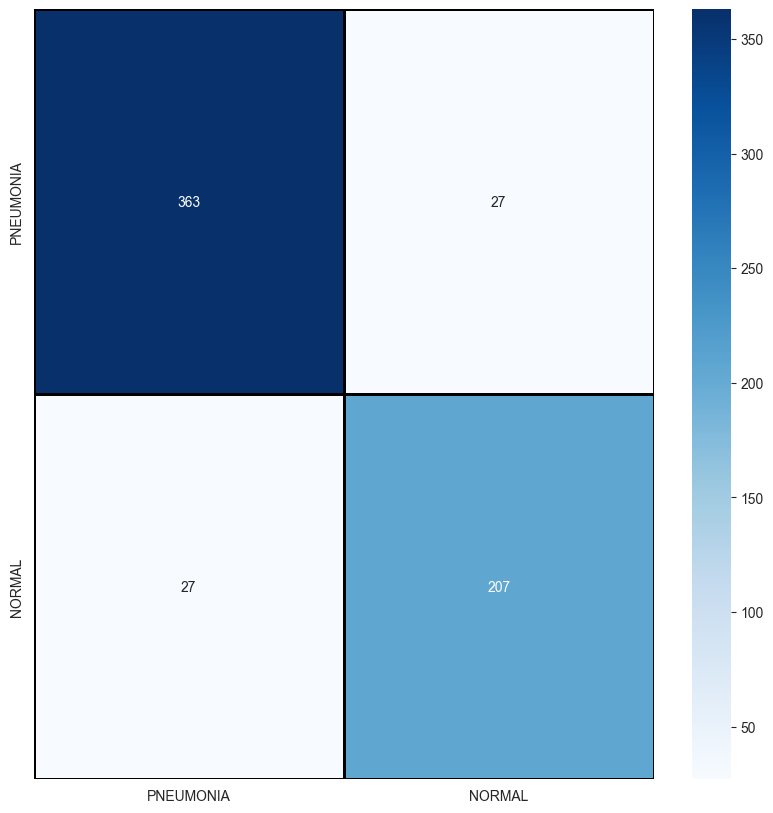

In [24]:
plt.figure(figsize = (10,10))
sns.heatmap(cm,cmap= "Blues", linecolor = 'black' , linewidth = 1 , annot = True, fmt='',xticklabels = labels,yticklabels = labels)

In [25]:
correct = np.nonzero(predictions == y_test)[0]
incorrect = np.nonzero(predictions != y_test)[0]

### Examples of Correct Predictions

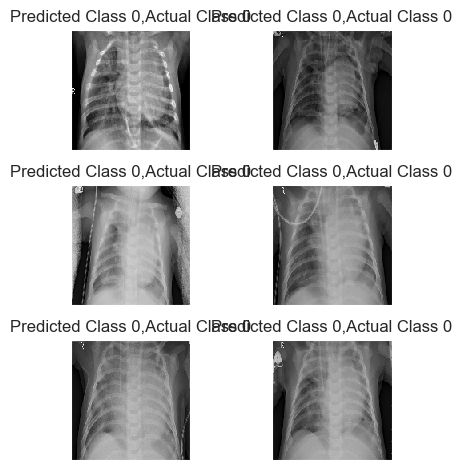

In [26]:
i = 0
for c in correct[:6]:
    plt.subplot(3,2,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_test[c].reshape(150,150), cmap="gray", interpolation='none')
    plt.title("Predicted Class {},Actual Class {}".format(predictions[c], y_test[c]))
    plt.tight_layout()
    i += 1

### Examples of Misclassifications

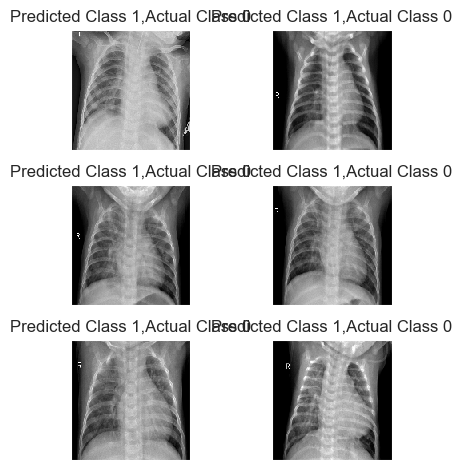

In [27]:
i = 0
for c in incorrect[:6]:
    plt.subplot(3,2,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_test[c].reshape(150,150), cmap="gray", interpolation='none')
    plt.title("Predicted Class {},Actual Class {}".format(predictions[c], y_test[c]))
    plt.tight_layout()
    i += 1

In [28]:
model.save('pneumonia_cnn_model.keras')
print("Model saved to:", os.path.abspath('pneumonia_cnn_model.keras'))

Model saved to: c:\Users\RRIBEI44\Documents\personal_project\modelagem_comp_2\pneumonia_cnn_model.keras


# Single-Image Inference

Testing the model on individual validation images to visualize predictions with confidence scores.

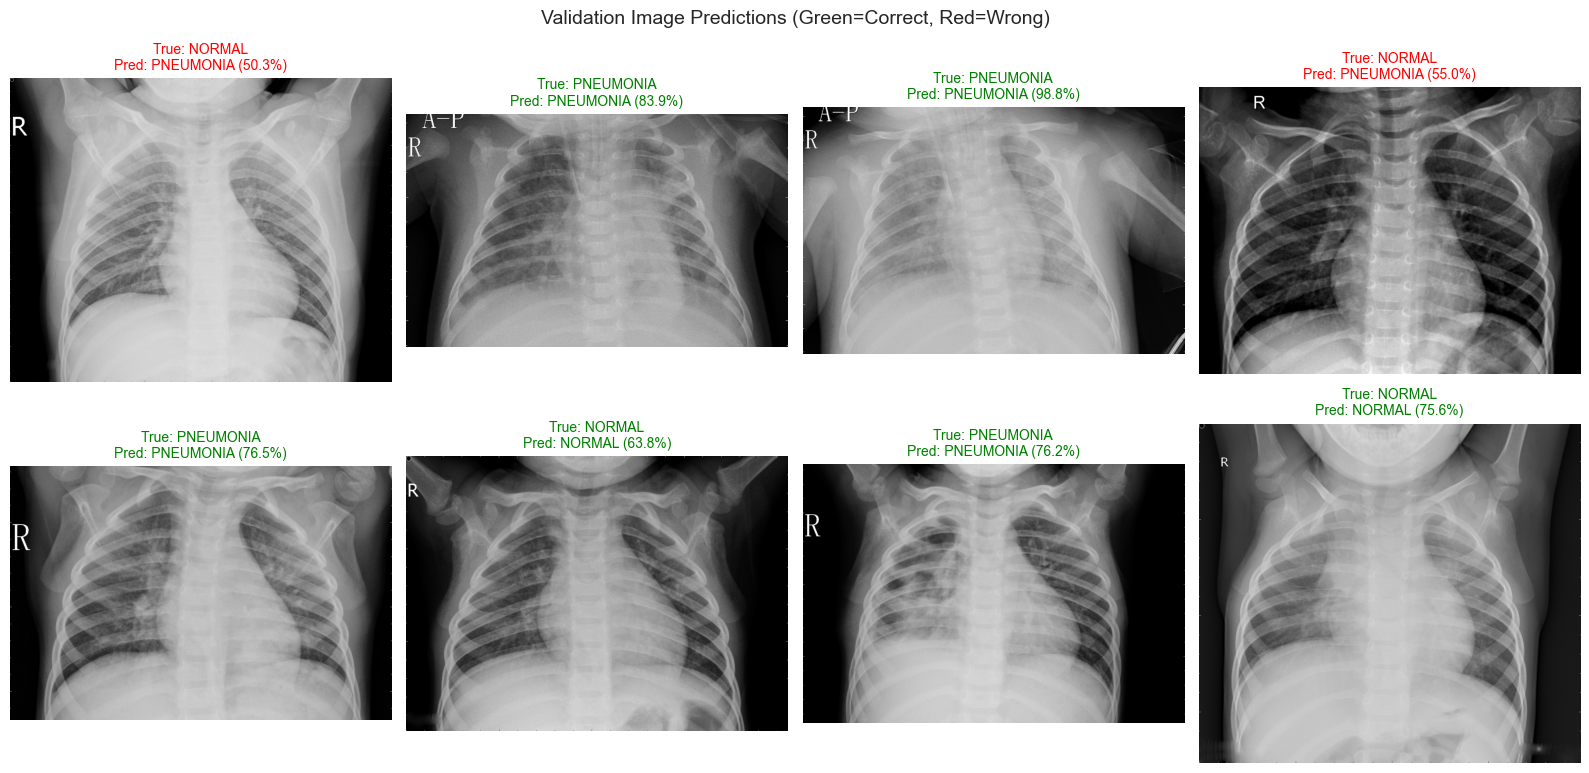

In [29]:
import random

def predict_image(image_path):
    """Load an image, preprocess it, and predict using the trained model."""
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    resized = cv2.resize(img, (img_size, img_size))
    normalized = resized / 255.0
    reshaped = normalized.reshape(1, img_size, img_size, 1)
    prediction = model.predict(reshaped, verbose=0)
    confidence = prediction[0][0]
    predicted_label = "NORMAL" if confidence >= 0.5 else "PNEUMONIA"
    return predicted_label, confidence

# Pick random images from the validation set
val_dir = os.path.join(DATA_DIR, 'val')
val_images = []
for label in labels:
    label_dir = os.path.join(val_dir, label)
    for img_name in os.listdir(label_dir):
        val_images.append((os.path.join(label_dir, img_name), label))

random.shuffle(val_images)
samples = val_images[:8]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for idx, (img_path, true_label) in enumerate(samples):
    predicted_label, confidence = predict_image(img_path)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    ax = axes[idx // 4, idx % 4]
    ax.imshow(img, cmap='gray')
    color = 'green' if predicted_label == true_label else 'red'
    conf_pct = confidence if predicted_label == "NORMAL" else 1 - confidence
    ax.set_title(f"True: {true_label}\nPred: {predicted_label} ({conf_pct:.1%})", color=color, fontsize=10)
    ax.axis('off')

plt.suptitle("Validation Image Predictions (Green=Correct, Red=Wrong)", fontsize=14)
plt.tight_layout()
plt.show()